In [1]:
# Quick iteration, autoreload, does not have to restart the kernel

%load_ext autoreload
%autoreload 2

In [2]:
from utils import get_dataset_path

path = get_dataset_path()
print(path)

/Volumes/HP_P900/Users/tungnguyen/.cache/kagglehub/datasets/sowmyaabirami/thyroid-ultrasound-dataset/versions/1


In [3]:
import os 
os.listdir(path)

['malignant', 'benign']

In [4]:
malignant_path = os.path.join(path, 'malignant')
benign_path = os.path.join(path, 'benign')

4780
(500, 718, 3)


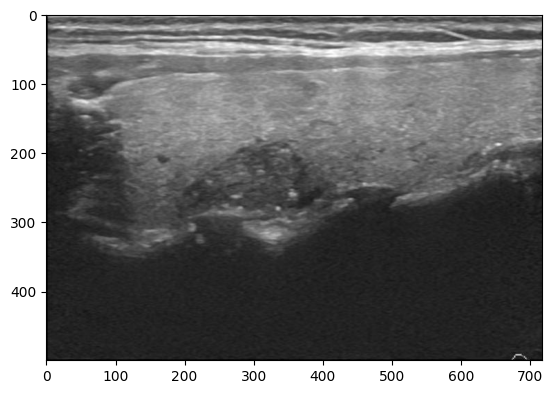

In [5]:
malignant_img_path_list = [os.path.join(malignant_path, name) for name in os.listdir(malignant_path)]
print(len(malignant_img_path_list))

import cv2
img = cv2.imread(malignant_img_path_list[0])
print(img.shape)

import matplotlib.pyplot as plt
plt.imshow(img)

2278
(500, 718, 3)


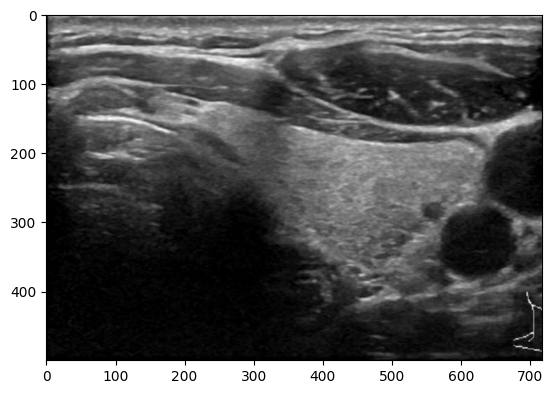

In [6]:
benign_img_path_list = [os.path.join(benign_path, name) for name in os.listdir(benign_path)]
print(len(benign_img_path_list))

img = cv2.imread(benign_img_path_list[0])
print(img.shape)
plt.imshow(img)

In [7]:
# Analyze image size distribution
malignant_img_sizes = [cv2.imread(img_path).shape for img_path in malignant_img_path_list]
benign_img_sizes = [cv2.imread(img_path).shape for img_path in benign_img_path_list]

import numpy as np
malignant_img_sizes_np = np.array(malignant_img_sizes)
benign_img_sizes_np = np.array(benign_img_sizes)


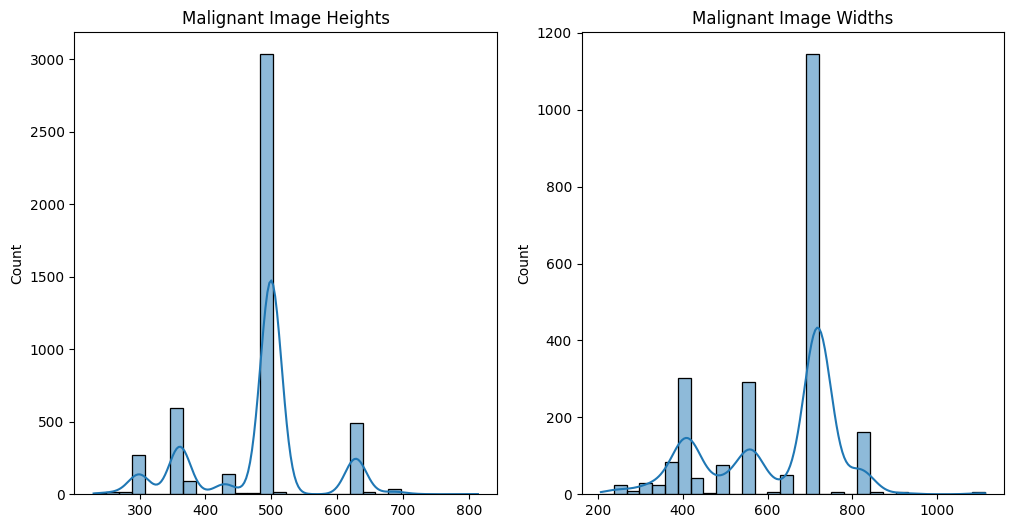

In [8]:
import seaborn as sns
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(malignant_img_sizes_np[:, 0], bins=30, kde=True)
plt.title('Malignant Image Heights')
plt.subplot(1, 2, 2)
sns.histplot(benign_img_sizes_np[:, 1], bins=30, kde=True)
plt.title('Malignant Image Widths')
plt.show()

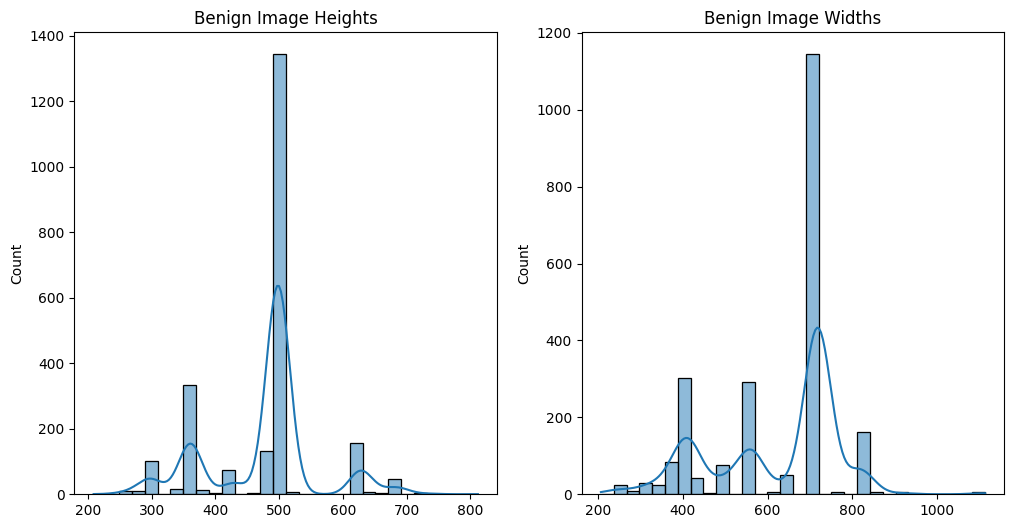

In [9]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(benign_img_sizes_np[:, 0], bins=30, kde=True)
plt.title('Benign Image Heights')
plt.subplot(1, 2, 2)
sns.histplot(benign_img_sizes_np[:, 1], bins=30, kde=True)
plt.title('Benign Image Widths')
plt.show()

## Test Dataset class

False
torch.Size([1, 500, 700])


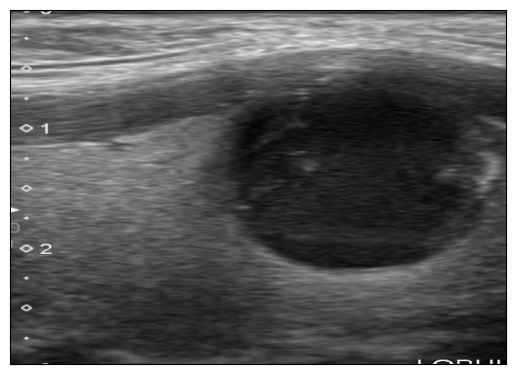

In [12]:
from datasets_utils import get_datasets

train_dataset, _ , _ = get_datasets()

image, label = train_dataset[0]

import torchvision.transforms.functional as F

def show(imgs):
    if not isinstance(imgs, list):
        imgs = [imgs]
    fix, axs = plt.subplots(ncols=len(imgs), squeeze=False)
    for i, img in enumerate(imgs):
        img = img.detach()
        img = F.to_pil_image(img)
        axs[0, i].imshow(np.asarray(img), cmap='gray')
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

show(image)
print(label)
print(image.shape)

In [ ]:
# Check the distribution and data type



In [ ]:
# imagec0, imagec1, imagec2 = image[0], image[1], image[2]
# show([imagec0, imagec1, imagec2])

In [ ]:
# import torch

# img = image

# print(img.shape)

# # Kiểm tra 3 channel có giống nhau không
# print(torch.allclose(img[0], img[1]))  # True nếu R == G
# print(torch.allclose(img[1], img[2]))  # True nếu G == B

# # Xem sự khác biệt nếu có
# print((img[0] - img[1]).abs().max())
# print((img[1] - img[2]).abs().max())